## Single Cell RNA sequencing data analysis Using scanpy Pipeline ##


## PREREQUISITES

In [1]:
# uv is faster than pip
!pip install uv


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# Creating a venv 
!uv venv scrnaseq

Using CPython 3.14.0 interpreter at: C:\Users\sanka\AppData\Local\Programs\Python\Python314\python.exe
Creating virtual environment at: scrnaseq
Activate with: scrnaseq\Scripts\activate


In [16]:
# Installing Jupyter ipykernel for Registering venv as a kernel
!uv pip install jupyter ipykernel

Using Python 3.14.0 environment at: scrnaseq
Resolved 97 packages in 1.84s
Prepared 84 packages in 12.00s
Installed 84 packages in 2.22s
 + anyio==4.12.0
 + argon2-cffi==25.1.0
 + argon2-cffi-bindings==25.1.0
 + arrow==1.4.0
 + asttokens==3.0.1
 + async-lru==2.0.5
 + babel==2.17.0
 + beautifulsoup4==4.14.3
 + bleach==6.3.0
 + certifi==2025.11.12
 + cffi==2.0.0
 + charset-normalizer==3.4.4
 + comm==0.2.3
 + debugpy==1.8.19
 + decorator==5.2.1
 + defusedxml==0.7.1
 + executing==2.2.1
 + fastjsonschema==2.21.2
 + fqdn==1.5.1
 + h11==0.16.0
 + httpcore==1.0.9
 + httpx==0.28.1
 + ipykernel==7.1.0
 + ipython==9.8.0
 + ipython-pygments-lexers==1.1.1
 + ipywidgets==8.1.8
 + isoduration==20.11.0
 + jedi==0.19.2
 + json5==0.12.1
 + jsonpointer==3.0.0
 + jsonschema==4.25.1
 + jsonschema-specifications==2025.9.1
 + jupyter==1.1.1
 + jupyter-client==8.7.0
 + jupyter-console==6.6.3
 + jupyter-core==5.9.1
 + jupyter-events==0.12.0
 + jupyter-lsp==2.3.0
 + jupyter-server==2.17.0
 + jupyter-server-term

In [20]:
# Registering the venv as a kernel
!python -m ipykernel install --user --name=scrnaseq --display-name="scrnaseq"

Installed kernelspec scrnaseq in C:\Users\sanka\AppData\Roaming\jupyter\kernels\scrnaseq


In [1]:
## Install Packages / Libraries 

!uv pip install pandas numpy scanpy scvi-tools  

Using Python 3.14.0 environment at: .
Audited 4 packages in 1.46s


In [3]:
!uv pip list

Package                   Version
------------------------- -----------
absl-py                   2.3.1
aiohappyeyeballs          2.6.1
aiohttp                   3.13.2
aiosignal                 1.4.0
anndata                   0.12.7
anyio                     4.12.0
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
array-api-compat          1.12.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.0.5
attrs                     25.4.0
babel                     2.17.0
beautifulsoup4            4.14.3
bleach                    6.3.0
certifi                   2025.11.12
cffi                      2.0.0
charset-normalizer        3.4.4
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.19
decorator                 5.2.1
defusedxml                0.7.1
docrep                    0.3.2
donfig                    0.8.1.post1
executing 

Using Python 3.14.0 environment at: .


## LOAD DATA 

In [1]:
# Load packages 

import scanpy as sc
import pandas as pd
import numpy as np
import scvi 
import matplotlib.pyplot as plt 

In [10]:
# adata = sc.read_10x_mtx/sc.read_10x_h5/sc.read_h5ad("path/to/the/files")
# reads can be in different format

# laoding the  filtered data 
adata = sc.read_10x_h5("C:\\Users\\sanka\\Desktop\\scrnaseq\\data\\pbmc_unsorted_3k_filtered_feature_bc_matrix.h5")

# Instead of using \\ i could've used a "r-string" raw string which doesn't considers \ as an escape character 

C:\Users\sanka\Desktop\scrnaseq\Lib\site-packages\anndata\_core\anndata.py:1808: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
C:\Users\sanka\Desktop\scrnaseq\Lib\site-packages\anndata\_core\anndata.py:1808: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [11]:
# Make the var(gene) name unique 
adata.var_names_make_unique()

In [12]:
# Checking whether the names are unique now or not 
adata.var_names.is_unique

True

## EDA

In [13]:
# INITIAL EDA 

print(f"Total cells : {len(adata.obs)}" )
print(f"Total Genes : {len(adata.var)}" )

# print(f"sparsity = {1 - sum(adata.X > 0) / len(adata.obs) * len(adata.var)} " )
### NotImplementedError: subtracting a sparse array from a nonzero scalar is not supported ###

Total cells : 3009
Total Genes : 36601


In [14]:
print(f"Total cells : {len(adata.obs)}" )
print(f"Total Genes : {len(adata.var)}" )

Total cells : 3009
Total Genes : 36601


In [15]:
total_elements = adata.X.shape[0] * adata.X.shape[1]
nonzero_elements = adata.X.nnz
zero_elements = total_elements - nonzero_elements
sparsity = zero_elements / total_elements

print(f"Sparsity : {(sparsity*100):.2f}%")

Sparsity : 95.68%


In [16]:
# UMI Distribution 

umi_counts = adata.X.sum(axis=0).A1 # .A1 converts the result to a 1D NumPy array (single entries ).
print(f"Median UMI per cell : {np.median(umi_counts):.2f}")
print(f"Cells with >500 counts : {(umi_counts > 500).sum()}")

Median UMI per cell : 6.00
Cells with >500 counts : 3851


In [17]:
# Calculating the qc metrices of adata
sc.pp.calculate_qc_metrics(adata,log1p=False,inplace=True)

In [18]:
adata.var

,gene_ids,feature_types,genome,interval,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts
MIR1302-2HG,ENSG00000243485,Gene Expression,GRCh38,chr1:29553-30267,0,0.000000,100.000000,0.0
FAM138A,ENSG00000237613,Gene Expression,GRCh38,chr1:36080-36081,0,0.000000,100.000000,0.0
OR4F5,ENSG00000186092,Gene Expression,GRCh38,chr1:65418-69055,0,0.000000,100.000000,0.0
AL627309.1,ENSG00000238009,Gene Expression,GRCh38,chr1:120931-133723,16,0.005317,99.468262,16.0
AL627309.3,ENSG00000239945,Gene Expression,GRCh38,chr1:91104-91105,1,0.000332,99.966766,1.0
...,...,...,...,...,...,...,...,...
AC141272.1,ENSG00000277836,Gene Expression,GRCh38,KI270728.1:1270983-1270984,0,0.000000,100.000000,0.0
AC023491.2,ENSG00000278633,Gene Expression,GRCh38,KI270731.1:13000-13001,0,0.000000,100.000000,0.0
AC007325.1,ENSG00000276017,Gene Expression,GRCh38,KI270734.1:72410-72411,2,0.000665,99.933533,2.0
AC007325.4,ENSG00000278817,Gene Expression,GRCh38,KI270734.1:131493-131494,8,0.002659,99.734131,8.0


In [19]:
adata.obs

,n_genes_by_counts,total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes
AAACAGCCAACAGGTG-1,1003,1796.0,35.356347,42.316258,53.452116,71.993318
AAACATGCAACAACAA-1,1956,3997.0,22.867150,29.697273,39.104328,57.668251
AAACATGCACCTGGTG-1,102,460.0,88.695652,99.565217,100.000000,100.000000
AAACCAACACAGCCTG-1,870,1565.0,35.079872,43.450479,56.230032,76.357827
AAACCAACAGCAAGAT-1,968,1574.0,28.144854,36.975858,49.682338,70.266836
...,...,...,...,...,...,...
TTTGTCTAGTCTATGA-1,1140,1877.0,20.298348,29.621737,42.461375,65.903037
TTTGTGGCAGCACGAA-1,1175,2088.0,28.879310,36.590038,47.365900,67.672414
TTTGTGGCATCGCTCC-1,1289,2112.0,18.371212,26.515152,38.068182,62.642045
TTTGTGTTCACTTCAT-1,1596,3701.0,42.312888,47.122399,54.660902,70.386382


# Preprocessing / Quality Control

In [20]:
# Getting How many Genes are there that are expressed in less than 3 cells 
print(f"Min Number of genes expressed across all cells : {min(adata.var["n_cells_by_counts"])} ")
print(f"Max Number of genes expressed across all cells : {max(adata.var["n_cells_by_counts"])} ")
Gene_exp = adata.var_names[(adata.var["n_cells_by_counts"] < 3 )].tolist()
print(f"Genes Expressed in less than 100 cells : {len(Gene_exp)} \n ")  

# Getting How many Cells have less than 100 genes expressed 
print(f"Min Number of genes in a cell : {min(adata.obs["n_genes_by_counts"])} ")
print(f"Max Number of genes in a cell : {max(adata.obs["n_genes_by_counts"])} ")
Per_cell_gene_exp = adata.obs_names[(adata.obs["n_genes_by_counts"]< 100 )].tolist()
print(f"Number of cells with less than 100 genes expressed ( Insignificant ) : {len(Per_cell_gene_exp)}")

Min Number of genes expressed across all cells : 0 
Max Number of genes expressed across all cells : 2980 
Genes Expressed in less than 100 cells : 15259 
 
Min Number of genes in a cell : 35 
Max Number of genes in a cell : 5521 
Number of cells with less than 100 genes expressed ( Insignificant ) : 39


In [21]:
# BASIC FILTERING 
sc.pp.filter_genes(adata, min_cells = 3 ) 
sc.pp.filter_cells(adata, min_genes = 100 )

Gene_exp = adata.var_names[(adata.var["n_cells_by_counts"] < 3)].tolist()
Per_cell_gene_exp = adata.obs_names[(adata.obs["n_genes_by_counts"]< 100 )].tolist()
print(f"Genes Expressed in less than 3 cells : {len(Gene_exp)} ")
print(f"Cells with less than 200 gene expression : {len(Per_cell_gene_exp)} ")

Genes Expressed in less than 3 cells : 0 
Cells with less than 200 gene expression : 0 


In [22]:
print(f"Total cells after basic filtering  : {len(adata.obs)}" )
print(f"Total Genes  after basic filtering : {len(adata.var)}" )

Total cells after basic filtering  : 2969
Total Genes  after basic filtering : 21342


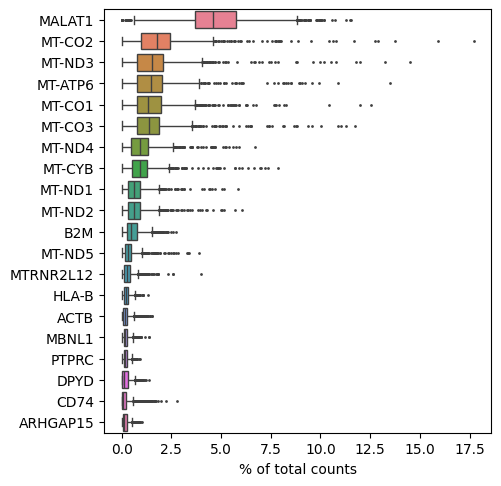

In [23]:
# PLotting the top 20 highly expressed genes
sc.pl.highest_expr_genes(adata, n_top=20)

In [24]:
adata_qc = adata.copy()

# Identify gene types
adata_qc.var['mt'] = adata_qc.var_names.str.startswith('MT-')
adata_qc.var['ribo'] = adata_qc.var_names.str.startswith(('RPS', 'RPL'))
adata_qc.var['hemoglobin'] = adata_qc.var_names.str.contains('^HB[^(P)]')


print(f"Found {adata_qc.var["mt"].sum()} Mitochondrial genes. " )
print(f"Found {adata_qc.var["ribo"].sum()} Ribosomal genes. " )
print(f"Found {adata_qc.var["hemoglobin"].sum()} Hemoglobin genes. " )

Found 13 Mitochondrial genes. 
Found 97 Ribosomal genes. 
Found 4 Hemoglobin genes. 


In [25]:
# # plotting qc metrices

# # Set up the figure and axes objects for a 3x2 grid
# fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 18))
# # ----- This will create a 3,2 array of axes [[ax1, ax2], [ax3, ax4], [ax5, ax6]] ------


# # sc.pl.hist(adata_qc, keys="n_genes_by_counts" , show=False , bins= 50 )
# ## ERORR : module 'scanpy.plotting' has no attribute 'hist'


# # First plot : Plots of total counts of genes in each cell ( Genes per cell ) 

# ax1_hist = axes[0,0]
# plt.hist(adata_qc.obs["n_genes_by_counts"] , bins = 50 , alpha = 0.7, color = "steelblue", edgecolor = 'black')
# plt.xlabel("Genes per cell")
# plt.ylabel("Number of cells ")
# plt.title("Gene per cell distribution")
# plt.axvline(np.median(adata.obs["n_genes_by_counts"]),color="red",linestyle = "--" , label = f"Median {np.median(adata.obs["n_genes_by_counts"]):.0f} " )
# plt.legend()
# plt.show()

# # plt.figure(figsize = (10,6))
# plt.subplot(3,2,2)
# sc.pl.violin(adata_qc , "n_genes_by_counts" , jitter=0.7)
# # Second pLot : Histogram plot of total Umi counts per cell 

# # plt.figure(figsize = (10,6))
# plt.subplot(3,2,3)
# plt.hist(adata_qc.obs["total_counts"] , bins = 50 , alpha = 0.7, color = "yellow", edgecolor = 'black')
# plt.xlabel("UMI Detected per cell")
# plt.ylabel("Number of cells ")
# plt.title("UMI distribution")
# plt.axvline(np.median(adata.obs["total_counts"]),color="red",linestyle = "--" , label = f"Median {np.median(adata.obs["total_counts"]):.0f} " )
# plt.legend()
# plt.show()

# # plt.hist(adata_qc.obs["n_genes_by_counts"] , bins = 50 , alpha = 0.7, color = "steelblue", edgecolor = 'black')
# # plt.xlabel("Genes per cell")
# # plt.ylabel("Number of cells ")
# # plt.title("Gene per cell distribution")
# # plt.axvline(np.median(adata.obs["n_genes_by_counts"]),color="red",linestyle = "--" , label = f"Median {np.median(adata.obs["n_genes_by_counts"]):.0f} " )
# # plt.legend()
# # plt.show()





In [26]:
sc.pp.calculate_qc_metrics(adata_qc, log1p=False,percent_top=None, qc_vars=["mt","ribo","hemoglobin"], inplace=True)

In [27]:
adata_qc.obs

,n_genes_by_counts,total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,n_genes,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,total_counts_hemoglobin,pct_counts_hemoglobin
AAACAGCCAACAGGTG-1,1001,1794.0,35.356347,42.316258,53.452116,71.993318,1001,328.0,18.283167,113.0,6.298774,0.0,0.000000
AAACATGCAACAACAA-1,1955,3996.0,22.867150,29.697273,39.104328,57.668251,1955,325.0,8.133134,33.0,0.825826,0.0,0.000000
AAACATGCACCTGGTG-1,102,460.0,88.695652,99.565217,100.000000,100.000000,102,358.0,77.826088,23.0,5.000000,0.0,0.000000
AAACCAACACAGCCTG-1,868,1563.0,35.079872,43.450479,56.230032,76.357827,868,263.0,16.826616,86.0,5.502239,0.0,0.000000
AAACCAACAGCAAGAT-1,967,1573.0,28.144854,36.975858,49.682338,70.266836,967,191.0,12.142404,91.0,5.785124,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCTAGTCTATGA-1,1138,1875.0,20.298348,29.621737,42.461375,65.903037,1138,104.0,5.546667,16.0,0.853333,0.0,0.000000
TTTGTGGCAGCACGAA-1,1175,2088.0,28.879310,36.590038,47.365900,67.672414,1175,305.0,14.607279,36.0,1.724138,1.0,0.047893
TTTGTGGCATCGCTCC-1,1287,2110.0,18.371212,26.515152,38.068182,62.642045,1287,8.0,0.379147,17.0,0.805687,0.0,0.000000
TTTGTGTTCACTTCAT-1,1593,3698.0,42.312888,47.122399,54.660902,70.386382,1593,1165.0,31.503517,56.0,1.514332,0.0,0.000000


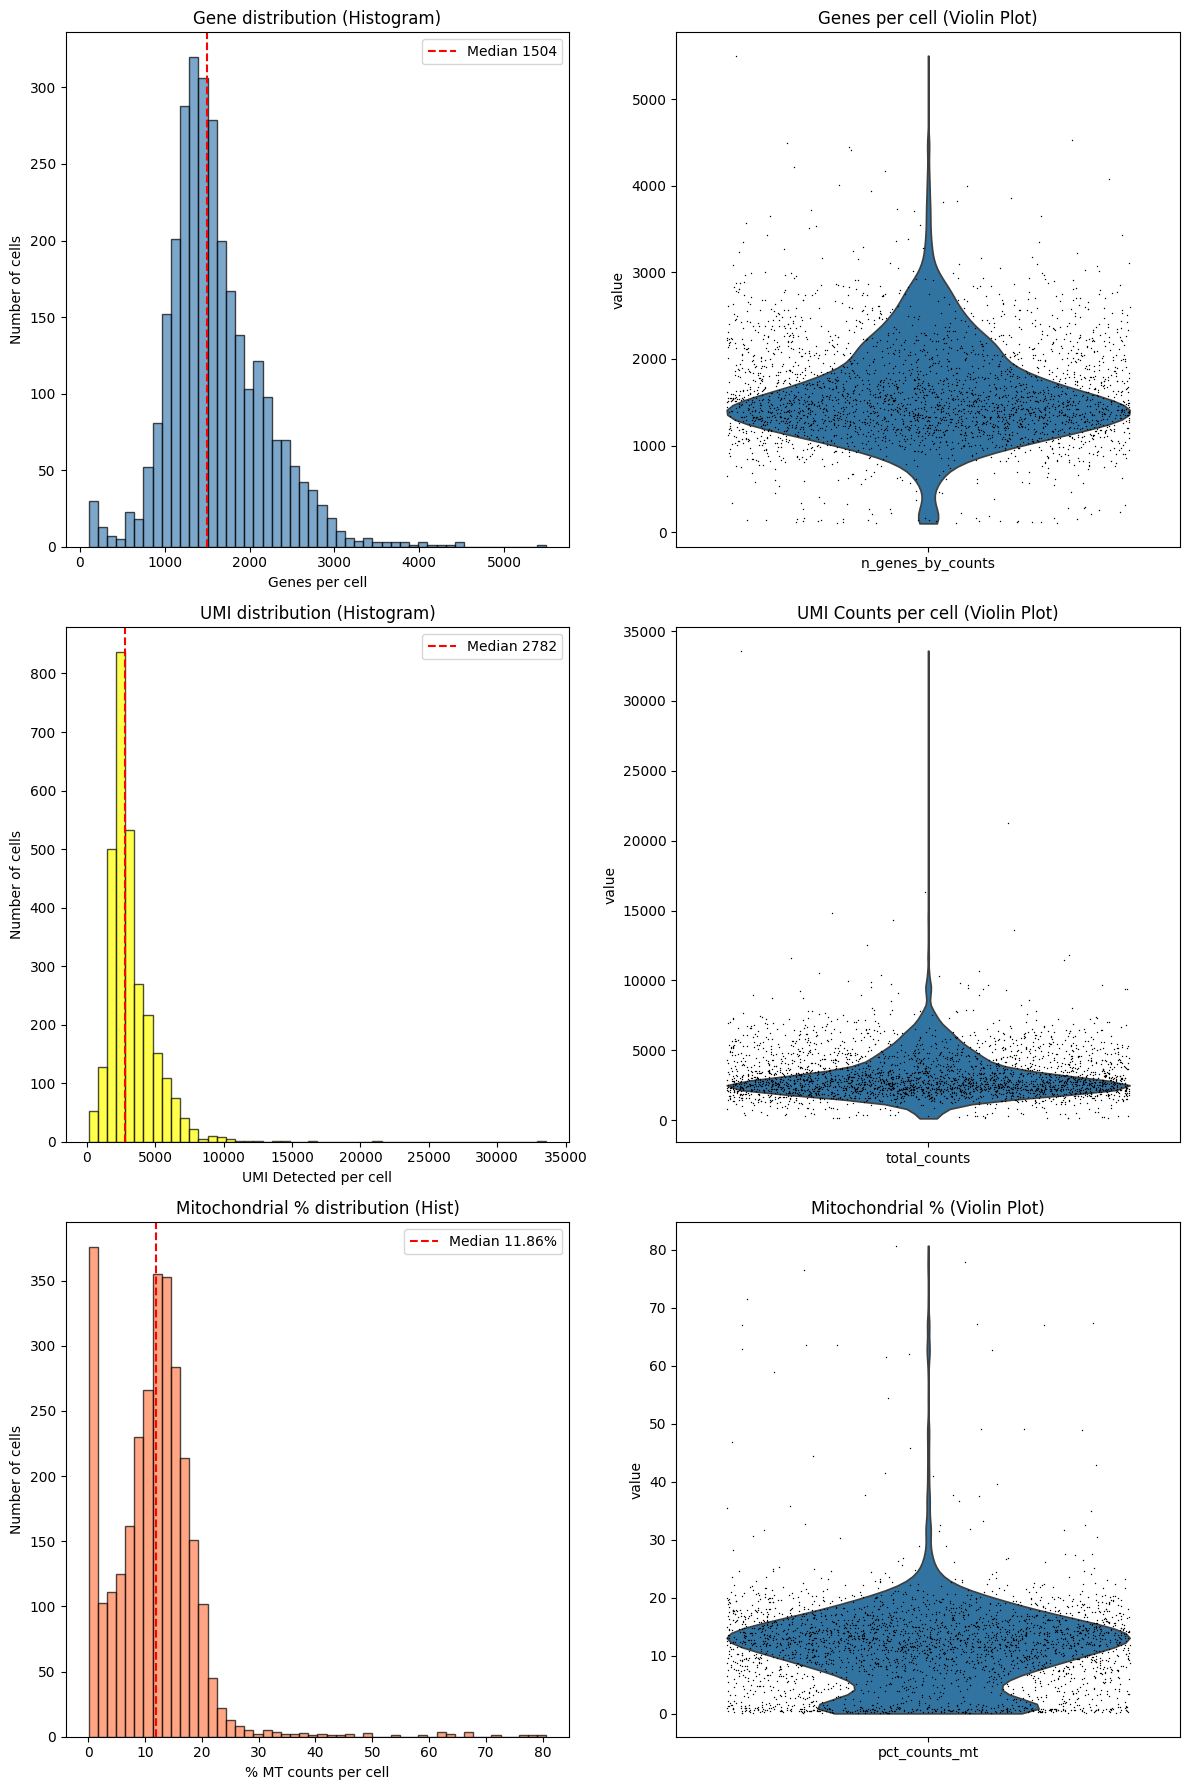

In [28]:
# More Structured Through gpts

# Plotting qc metrices

# Set up the figure and axes objects for a 3x2 grid
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 18))
# axes is now a 2D numpy array: [[ax1, ax2], [ax3, ax4], [ax5, ax6]]

# --- Row 1: Genes per Cell ---
# 1a: Histogram
ax1_hist = axes[0, 0]
ax1_hist.hist(adata_qc.obs["n_genes_by_counts"], bins=50, alpha=0.7, color="steelblue", edgecolor='black')
ax1_hist.set_xlabel("Genes per cell")
ax1_hist.set_ylabel("Number of cells")
ax1_hist.set_title("Gene distribution (Histogram)")
median_genes = np.median(adata.obs["n_genes_by_counts"])
ax1_hist.axvline(median_genes, color="red", linestyle="--", label=f"Median {median_genes:.0f}")
ax1_hist.legend()

# 1b: Violin Plot
ax1_viol = axes[0, 1]
sc.pl.violin(adata_qc, "n_genes_by_counts", jitter=0.4, ax=ax1_viol, show=False )
ax1_viol.set_title("Genes per cell (Violin Plot)")
ax1_viol.set_xlabel("") # Clear redundant x-label

# --- Row 2: UMI Counts per Cell ---
# 2a: Histogram
ax2_hist = axes[1, 0]
ax2_hist.hist(adata_qc.obs["total_counts"], bins=50, alpha=0.7, color="yellow", edgecolor='black')
ax2_hist.set_xlabel("UMI Detected per cell")
ax2_hist.set_ylabel("Number of cells")
ax2_hist.set_title("UMI distribution (Histogram)")
median_counts = np.median(adata.obs["total_counts"])
ax2_hist.axvline(median_counts, color="red", linestyle="--", label=f"Median {median_counts:.0f}")
ax2_hist.legend()

# 2b: Violin Plot
ax2_viol = axes[1, 1]
sc.pl.violin(adata_qc, "total_counts", jitter=0.4, ax=ax2_viol, show=False)
ax2_viol.set_title("UMI Counts per cell (Violin Plot)")
ax2_viol.set_xlabel("")

# --- Row 3: Mitochondrial Distribution by Percentage---

# 3a: Histogram
ax3_hist = axes[2, 0]
ax3_hist.hist(adata_qc.obs["pct_counts_mt"], bins=50, alpha=0.7, color="coral", edgecolor='black')
ax3_hist.set_xlabel("% MT counts per cell")
ax3_hist.set_ylabel("Number of cells")
ax3_hist.set_title("Mitochondrial % distribution (Hist)")
median_mt = np.median(adata_qc.obs["pct_counts_mt"])
ax3_hist.axvline(median_mt, color="red", linestyle="--", label=f"Median {median_mt:.2f}%")
ax3_hist.legend()

# 3b: Violin Plot
ax3_viol = axes[2, 1]
sc.pl.violin(adata_qc, "pct_counts_mt", jitter=0.4, ax=ax3_viol, show=False)
ax3_viol.set_title("Mitochondrial % (Violin Plot)")
ax3_viol.set_xlabel("")


# Adjust layout to prevent titles/labels from overlapping
plt.tight_layout()
plt.show()


In [41]:
# Filtering the Mitochondrial cells 

high_mito = adata_qc.obs[(adata_qc.obs["pct_counts_mt"] > 20 )]
high_mito_index_list = high_mito.index.tolist()

adata_qc_1 = adata_qc.copy()

In [45]:
adata_qc_1 = adata_qc_1[~adata_qc_1.obs_names.isin(high_mito_index_list),:].copy()
adata_qc_1


AnnData object with n_obs × n_vars = 2777 × 21342
    obs: 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hemoglobin', 'pct_counts_hemoglobin'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'mt', 'ribo', 'hemoglobin'

In [21]:
adata_qc

AnnData object with n_obs × n_vars = 2938 × 9129
    obs: 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hemoglobin', 'pct_counts_hemoglobin'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'mt', 'ribo', 'hemoglobin'